### COMPARATIVA MODELOS **BASELINE** (200 CANCIONES - PRUEBA)

TABLA COMPARATIVA DE MODELOS (Piloto 200 canciones)


,Métrica,SimpleCNN (Baseline),CLAP (Zero-Shot)
0,ROC-AUC (Macro),0.7608,0.6587
1,mAP (LRAP),0.1523,0.1506
2,Accuracy @ Top-5,24.0000,23.0000


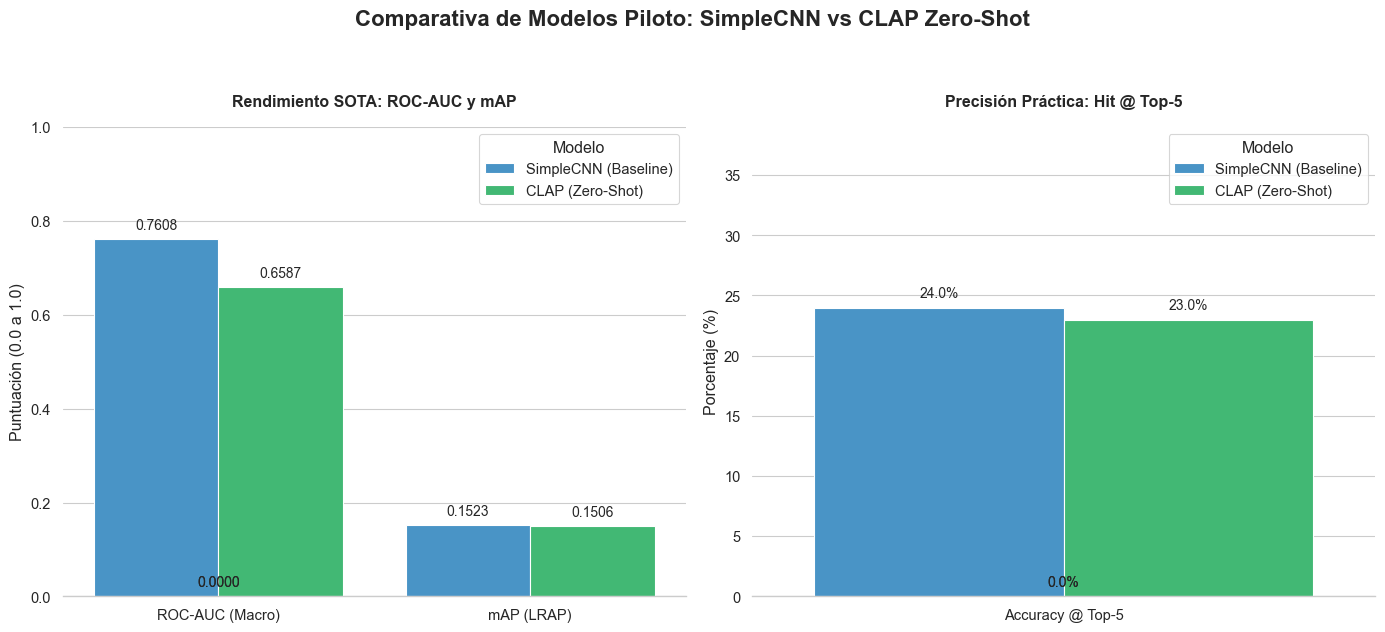

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── 1. INTRODUCIR LAS MÉTRICAS DE LOS DOS MODELOS ──
datos_comparativa = {
    'Métrica': ['ROC-AUC (Macro)', 'mAP (LRAP)', 'Accuracy @ Top-5'],
    'SimpleCNN (Baseline)': [0.7608, 0.1523, 24.0],  
    'CLAP (Zero-Shot)': [0.6587, 0.1506, 23.0]       
}

df_comp = pd.DataFrame(datos_comparativa)

# Mostrar la tabla elegante
print("TABLA COMPARATIVA DE MODELOS (Piloto 200 canciones)")
print("="*60)
display(df_comp)

# ── 2. PREPARAR DATOS PARA EL GRÁFICO (Formato Tidy) ──
# Transformamos la tabla para que Seaborn la entienda fácilmente
df_melted = df_comp.melt(id_vars='Métrica', var_name='Modelo', value_name='Valor')

# Separamos las métricas que van de 0 a 1 (AUC, mAP) de las que van de 0 a 100 (Top-5)
df_metricas_decimales = df_melted[df_melted['Métrica'].isin(['ROC-AUC (Macro)', 'mAP (LRAP)'])]
df_metricas_porcentaje = df_melted[df_melted['Métrica'] == 'Accuracy @ Top-5']

# ── 3. VISUALIZACIÓN PROFESIONAL ──
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: ROC-AUC y mAP (Escala 0 - 1)
sns.barplot(
    data=df_metricas_decimales, 
    x='Métrica', 
    y='Valor', 
    hue='Modelo', 
    palette=['#3498db', '#2ecc71'], # Azul para CNN, Verde para CLAP
    ax=ax1
)
ax1.set_title('Rendimiento SOTA: ROC-AUC y mAP', fontweight='bold', pad=15)
ax1.set_ylim(0, 1.0)
ax1.set_ylabel('Puntuación (0.0 a 1.0)')
ax1.set_xlabel('')

# Añadir los números encima de las barras (Gráfico 1)
for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.4f}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

# Gráfico 2: Accuracy @ Top 5 (Escala 0 - 100%)
sns.barplot(
    data=df_metricas_porcentaje, 
    x='Métrica', 
    y='Valor', 
    hue='Modelo', 
    palette=['#3498db', '#2ecc71'],
    ax=ax2
)
ax2.set_title('Precisión Práctica: Hit @ Top-5', fontweight='bold', pad=15)
ax2.set_ylim(0, max(df_metricas_porcentaje['Valor']) + 15) # Ajustar techo
ax2.set_ylabel('Porcentaje (%)')
ax2.set_xlabel('')

# Añadir los números encima de las barras (Gráfico 2)
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.1f}%", 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

# Ajustes finales
plt.suptitle('Comparativa de Modelos Piloto: SimpleCNN vs CLAP Zero-Shot', fontsize=16, fontweight='bold', y=1.05)
sns.despine(left=True)
plt.tight_layout()

# Guardar la imagen para el TFG
plt.savefig('comparativa_piloto_tfg.png', dpi=300, bbox_inches='tight')
plt.show()